# 3. Rapids
---

In [1]:
# Instalar bibliotecas necesarias
!uv pip install dask distributed --quiet  # Para trabajar con Dask
!uv pip install cudf-cu12 dask-cudf-cu12 --extra-index-url=https://pypi.nvidia.com
!uv pip install pyngrok --quiet  # Para exponer el dashboard de Dask
!uv pip install kagglehub # Para extraer el dataset directamente desde Kaggle

Checked 2 packages in 4ms
Checked 1 package in 1ms


In [2]:
# Importar librerías
from dask.distributed import Client, LocalCluster
from pyngrok import ngrok
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

## 3.0. Exponer el Dashboard de Dask con ngrok y configuración del clúster en modo CPU


In [3]:
# Función para exponer el dashboard de Dask con ngrok
def expose_dashboard(cluster):
    ngrok.set_auth_token("3DGUSrNgMvLKPTUmNUW5yTWO6gG_K8JaZSLeymSDNRoijoV1")
    public_url = ngrok.connect(8787)  # Puerto por defecto del dashboard de Dask
    print(f"El dashboard de Dask está disponible en: {public_url}")
    return public_url


def setup_cluster():
    cluster = LocalCluster(
        n_workers=2,  # número de workers
        threads_per_worker=2,  # hilos por worker
        memory_limit="7GB",  # límite de RAM por worker
        dashboard_address=":8787",  # dashboard en el puerto 8787
    )

    # Conectar al cluster
    client = Client(cluster)
    print(client)  # Mostrar información del cliente
    expose_dashboard(cluster)  # Exponer el dashboard
    return client


client_cpu = setup_cluster()

<Client: 'tcp://127.0.0.1:36567' processes=2 threads=4, memory=13.04 GiB>
El dashboard de Dask está disponible en: NgrokTunnel: "https://5710-88-98-121-210.ngrok-free.app" -> "http://localhost:8787"


## 3.1. Cargar y limpiar datos

In [4]:
import dask_cudf as dd
import os
import kagglehub

# Descargamos el dataset

dataset_name = "new-york-city/nyc-parking-tickets"
path = kagglehub.dataset_download(dataset_name)
os.makedirs(path, exist_ok=True)

# Cargamos cada archivo en un DataFrame de Dask distinto
tickets14 = dd.read_csv(
    os.path.join(
        path,
        "Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv",
    ),
    assume_missing=True,
    sample=10000,
)
print("Columnas y Tipos de datos 2014: \n", tickets14.dtypes)
print("Número de Columnas", len(set(tickets14.columns)))
print("--" * 30)
print()

tickets15 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2015.csv"),
    assume_missing=True,
    sample=10000,
)
print("Columnas y Tipos de datos 2015: \n", tickets15.dtypes)
print("Número de Columnas", len(set(tickets15.columns)))
print("--" * 30)
print()

tickets16 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2016.csv"),
    assume_missing=True,
    sample=10000,
)
print("Columnas y Tipos de datos 2016:\n", tickets16.dtypes)
print("Número de Columnas", len(set(tickets16.columns)))
print("--" * 30)
print()

tickets17 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2017.csv"),
    assume_missing=True,
    sample=10000,
)
print("Columnas y Tipos de datos 2017:\n", tickets17.dtypes)
print("Número de Columnas", len(set(tickets17.columns)))

[169246][23:52:09:795807][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[169246][23:52:09:947597][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[169246][23:52:09:970530][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.


Columnas y Tipos de datos 2014: 
 Summons Number                               float64
Plate ID                             string[pyarrow]
Registration State                   string[pyarrow]
Plate Type                           string[pyarrow]
Issue Date                           string[pyarrow]
Violation Code                               float64
Vehicle Body Type                    string[pyarrow]
Vehicle Make                         string[pyarrow]
Issuing Agency                       string[pyarrow]
Street Code1                                 float64
Street Code2                                 float64
Street Code3                                 float64
Vehicle Expiration Date                      float64
Violation Location                           float64
Violation Precinct                           float64
Issuer Precinct                              float64
Issuer Code                                  float64
Issuer Command                               float64
Issuer Squad

[169246][23:52:09:997571][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.


In [5]:
tickets = {
    "tickets14": tickets14,
    "tickets15": tickets15,
    "tickets16": tickets16,
    "tickets17": tickets17,
}

# Comparar columnas entre todos los pares de DataFrames
for name1, df1 in tickets.items():
    for name2, df2 in tickets.items():
        if name1 >= name2:
            continue
        if set(df1.columns) != set(df2.columns):
            print(f"Diferencia de columnas entre {name1} y {name2}")

Diferencia de columnas entre tickets14 y tickets17
Diferencia de columnas entre tickets15 y tickets17
Diferencia de columnas entre tickets16 y tickets17


2. Extraemos las celdas comunes

In [6]:
# Obtenemos las columnas comunes entre los DataFrames
common_cols = list(
    set(tickets14.columns).intersection(
        tickets15.columns, tickets16.columns, tickets17.columns
    )
)

3. Especifica el esquema de tipo de datos deseado para el DataFrame de Dask: convierte todas las columnas comunes a `'str'`.

- Ahora si, vamos a especificar el esquema del tipo de datos y no habrá así ningún problema con la incorrecta inferencia de tipos por parte del framework.

In [7]:
# Convertimos todas las columnas comunes a string y cargamos solamente estas
data_types = {col: "str" for col in common_cols}

tickets14 = dd.read_csv(
    os.path.join(
        path,
        "Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv",
    ),
    usecols=common_cols,
    dtype=data_types,
    blocksize="16MB",
)
tickets15 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2015.csv"),
    usecols=common_cols,
    dtype=data_types,
    blocksize="16MB",
)
tickets16 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2016.csv"),
    usecols=common_cols,
    dtype=data_types,
    blocksize="16MB",
)
tickets17 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2017.csv"),
    usecols=common_cols,
    dtype=data_types,
    blocksize="16MB",
)

[169246][23:52:10:159726][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[169246][23:52:10:189743][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[169246][23:52:10:225549][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[169246][23:52:10:242390][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[169246][23:52:10:276771][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[169246][23:52:10:291112][warning] Auto detection of compression type is su

In [8]:
# Comprobamos la correcta conversión
print("Tipos en tickets14:")
print(tickets14.dtypes)
print("\nTipos tickets15:")
print(tickets15.dtypes)
print("\nTipos tickets16:")
print(tickets16.dtypes)
print("\nTipos tickets17:")
print(tickets17.dtypes)

Tipos en tickets14:
Summons Number                       string[pyarrow]
Plate ID                             string[pyarrow]
Registration State                   string[pyarrow]
Plate Type                           string[pyarrow]
Issue Date                           string[pyarrow]
Violation Code                       string[pyarrow]
Vehicle Body Type                    string[pyarrow]
Vehicle Make                         string[pyarrow]
Issuing Agency                       string[pyarrow]
Street Code1                         string[pyarrow]
Street Code2                         string[pyarrow]
Street Code3                         string[pyarrow]
Vehicle Expiration Date              string[pyarrow]
Violation Location                   string[pyarrow]
Violation Precinct                   string[pyarrow]
Issuer Precinct                      string[pyarrow]
Issuer Code                          string[pyarrow]
Issuer Command                       string[pyarrow]
Issuer Squad              

4. Ahora que has limpiado los datos, carga los 4 archivos en un único DataFrame de Dask y hazlo persistente en RAM para un procesamiento posterior.

- Verifica el dashboard y espera hasta que todos los datos estén cargados en RAM. Esto puede tardar varios minutos.
- Toma una captura de pantalla de tu Dask Dashboard durante el proceso de carga e insértala en tu notebook de entrega. Revisa los bytes almacenados por cada worker y explica el concepto de "Spilling to disk", comentando si te encuentras en esta situación.
- Verifica y anota el número de particiones del DataFrame.
- Verifica y anota el número de filas, columnas y el tamaño en RAM del DataFrame.

In [9]:
# Cargamos los DataFrames en uno único
df = dd.concat([tickets14, tickets15, tickets16, tickets17], axis=0)

In [10]:
del tickets14, tickets15, tickets16, tickets17  # Liberar memoria

In [11]:
# Para el dataset en RAM hacemos:
print(df.info())

print(f"Nº de particiones: {df.npartitions}")
n_filas = df.shape[0].compute()  # N_FILAS
n_columnas = df.shape[1]  # N_COLUMNAS

print(f"\nNº de Filas: {n_filas}\nNº de columnas: {n_columnas}")
print(
    f"Tamaño aproximado en RAM (GBytes): {df.memory_usage(deep=True).sum().compute() / 1024**3}"
)

<class 'dask_cudf._expr.collection.DataFrame'>
Columns: 43 entries, Summons Number to Double Parking Violation
dtypes: object(43)None
Nº de particiones: 563

Nº de Filas: 42339438
Nº de columnas: 43
Tamaño aproximado en RAM (GBytes): 13.325831815600395


In [12]:
print(df.dtypes)

Summons Number                       object
Plate ID                             object
Registration State                   object
Plate Type                           object
Issue Date                           object
Violation Code                       object
Vehicle Body Type                    object
Vehicle Make                         object
Issuing Agency                       object
Street Code1                         object
Street Code2                         object
Street Code3                         object
Vehicle Expiration Date              object
Violation Location                   object
Violation Precinct                   object
Issuer Precinct                      object
Issuer Code                          object
Issuer Command                       object
Issuer Squad                         object
Violation Time                       object
Time First Observed                  object
Violation County                     object
Violation In Front Of Or Opposit

## 3.2. Calcular algunos filtros

1. Calcula el condado de NYC que recibió más multas durante el periodo de estudio.

In [14]:
# Calcular el condado con más multas usando value_counts
county_with_most_violations = (
    df["Violation County"].value_counts().nlargest(1).compute()
)

county = county_with_most_violations.index[0]
n_vio = county_with_most_violations.values[0]

print(
    f"El condado con más multas durante el periodo de estudio fue: {county} con {n_vio} multas."
)

El condado con más multas durante el periodo de estudio fue: NY con 14630069 multas.


In [14]:
del county_with_most_violations

---
2. Calcula los 10 coches que recibieron más multas durante el periodo de estudio. Utiliza la columna `'Plate ID'` para identificar cada coche.

In [15]:
# Seleccionamos 'Plate ID' que contiene el número de matrícula y contamos el número de multas en
# cada matrícula y nos quedamos con los 11 valores más altos
# porrque el primero se asocia a matrícula en blanco.
# Agrupamos por 'Plate ID' y realizamos el conteo

top_10_plates = df["Plate ID"].value_counts(sort=True).nlargest(11).compute()

# Imprimimos las 10 matrículas con el mayor número de multas
top_pd = top_10_plates.to_pandas()

# 3. Itera sobre el pandas.Series
for i, (plate, n) in enumerate(top_pd.items(), start=0):
    print(f"{i}º coche con más multas: {plate} -> {n}")

0º coche con más multas: BLANKPLATE -> 56717
1º coche con más multas: 47603MD -> 4003
2º coche con más multas: 49781MA -> 3534
3º coche con más multas: 2028685 -> 3497
4º coche con más multas: AN917T -> 3312
5º coche con más multas: 96087MA -> 3261
6º coche con más multas: 75225JW -> 3217
7º coche con más multas: 49839JG -> 3204
8º coche con más multas: AP300F -> 3190
9º coche con más multas: 62546JM -> 3169
10º coche con más multas: 16213TC -> 3152


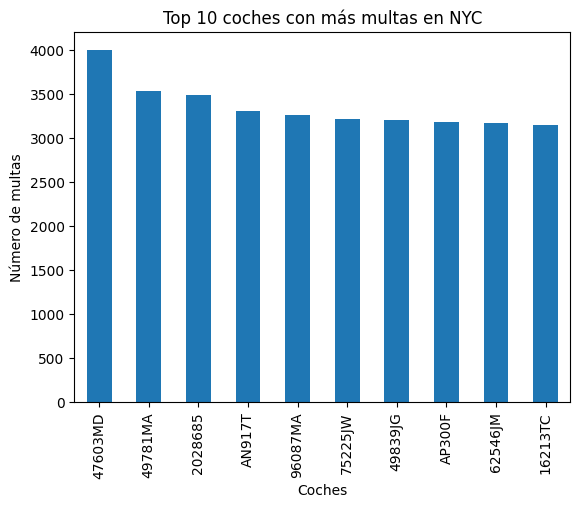

In [16]:
# Graficamos las 10 matrículas con el mayor número de multas mediante una gráfica de barras
top_pd[1:].plot(
    kind="bar",
    title="Top 10 coches con más multas en NYC",
    xlabel="Coches",
    ylabel="Número de multas",
)
plt.show()

In [17]:
del top_10_plates

---

3. Distribución de multas por mes (agregación temporal): Determinar el número total de multas emitidas en cada mes a lo largo del periodo y descubrir qué mes presenta la mayor cantidad de infracciones (para identificar posibles tendencias estacionales). (Pista: La columna de fecha de emisión Issue Date incluye fecha/hora de la multa): df['Issue Date'].dt.month para obtener el mes).


In [18]:
# Convertimos 'Issue Date' a datetime
df["Issue Date"] = df["Issue Date"].astype("datetime64[ns]")

# Extraemos el mes de la columna 'Issue Date' y generamos una nueva columna en el datframe con el
df["Issue Month"] = df["Issue Date"].dt.month

# Mediante 'Issue Month' realizamos el conteo y ordenamos de forma descendente
monthly_counts = (
    df["Issue Month"].value_counts().compute().sort_values(ascending=False)
)

# Mostramos la distribución de multas y el mes con más infracciones cometidas
print("Distribución de multas por mes:")
print(monthly_counts)

print(
    f"\nEl mes con más infracciones es: {monthly_counts.index[0]} con {monthly_counts.values[0]} multas"
)

Distribución de multas por mes:
Issue Month
10    3987212
3     3852356
5     3840294
1     3809913
9     3758123
6     3710541
4     3602097
11    3483306
8     3455617
12    3055935
2     3054514
7     2729530
Name: count, dtype: int64

El mes con más infracciones es: 10 con 3987212 multas


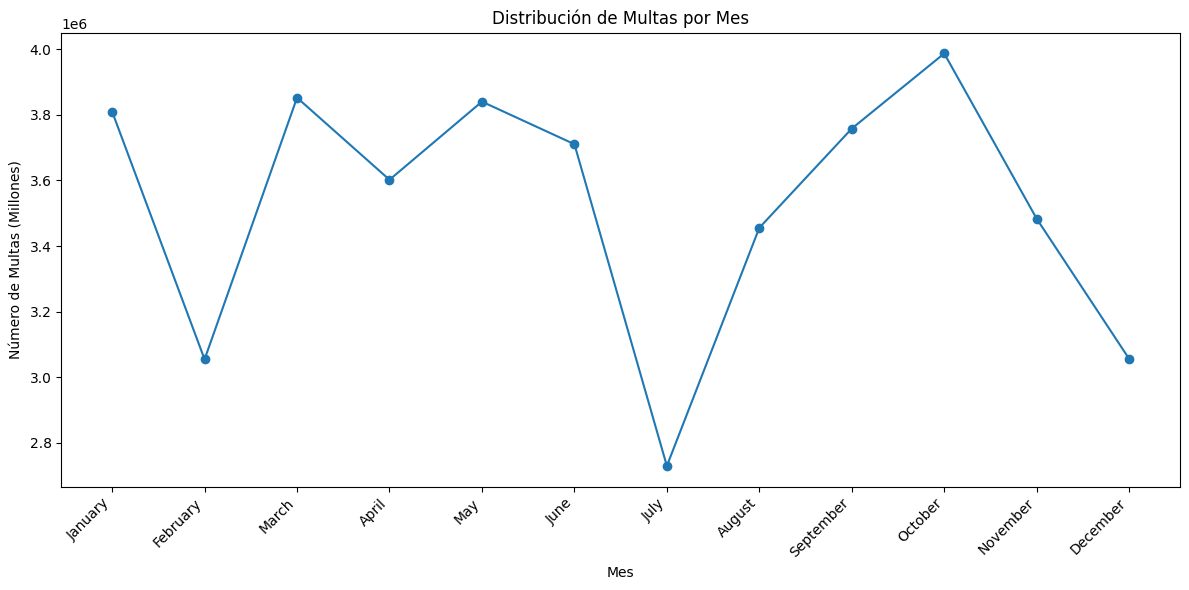

In [19]:
import calendar

monthly_counts = monthly_counts.to_pandas()
# Ordenamos por índice
monthly_counts = monthly_counts.sort_index()

# Mapeamos los índices a nombres de meses en inglés
month_names = [calendar.month_name[i] for i in monthly_counts.index]


plt.figure(figsize=(12, 6))
plt.plot(month_names, monthly_counts.values, marker="o")
plt.xlabel("Mes")
plt.ylabel("Número de Multas (Millones)")
plt.title("Distribución de Multas por Mes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [20]:
del monthly_counts

---

4. Horas del día con más multas (patrón diario): Analizar en qué horas del día se emiten más multas, identificando las horas pico de sanciones. (Pista: basándote en "Violation Time" extrae la hora del día de cada registro. Crea tu propia funcion "extract_hour" para obtener la hora - el formato es HORAMINUTOA/P, por ejemplo 0710P serían las 19:10. 0810A serían las 8:10-. Utiliza el método "map" para aplicar tu función a la entrada).


In [21]:
import cudf


def extract_hour_cudf(df: cudf.DataFrame) -> cudf.DataFrame:
    # 1) Lectura de la columna original
    tc = df["Violation Time"]

    # 2) Extraemos las dos primeras posiciones (hora) y el sufijo A/P
    hour_str = tc.str.slice(0, 2)  # p. ej. "08", "12"
    ampm = tc.str.slice(-1)  # p. ej. "A" o "P"

    # 3) Convertimos la parte numérica a valor, invalidos → NaN
    hour = cudf.to_numeric(hour_str, errors="coerce")

    # 4) Creamos máscaras para PM y medianoche (12 AM)
    pm_mask = (ampm == "P") & (hour < 12)  # sumar 12 si es PM excepto 12PM
    midnight_mask = (ampm == "A") & (hour == 12)  # convertir 12AM a 0

    # 5) Ajustamos la hora según las máscaras
    hour = hour.where(~pm_mask, hour + 12)  # si pm_mask True, hour+12
    hour = hour.where(~midnight_mask, 0)  # si midnight_mask True, set 0

    # 6) Filtramos valores inválidos:
    #    — longitud mínima del string (al menos "1A" = 2 chars)
    #    — no nulos
    #    — rango [0, 23]
    valid = (tc.str.len() >= 2) & hour.notnull() & (hour >= 0) & (hour < 24)
    # Colocamos None donde no sean válidos y cambiamos a entero con nulos
    hour = hour.where(valid, None).astype("Int32")

    # 7) Devolvemos un DataFrame con la nueva columna
    return cudf.DataFrame({"Violation Hour": hour})


# Definimos el “meta” para Dask-cuDF: esquema de la salida
meta = cudf.DataFrame({"Violation Hour": cudf.Series([], dtype="Int32")})

# Aplicamos la función en cada partición del DataFrame Dask-cuDF
tickets_hours = df.map_partitions(extract_hour_cudf, meta=meta)

# 3) Agrupamos por hora y contamos las multas
hourly_counts = (
    tickets_hours.groupby("Violation Hour")  # agrupación por cada hora 0–23
    .size()  # tamaño de cada grupo = número de multas
    .compute()  # ejecuta en el clúster y devuelve pandas Series
    .sort_index()  # ordena por hora ascendente
)

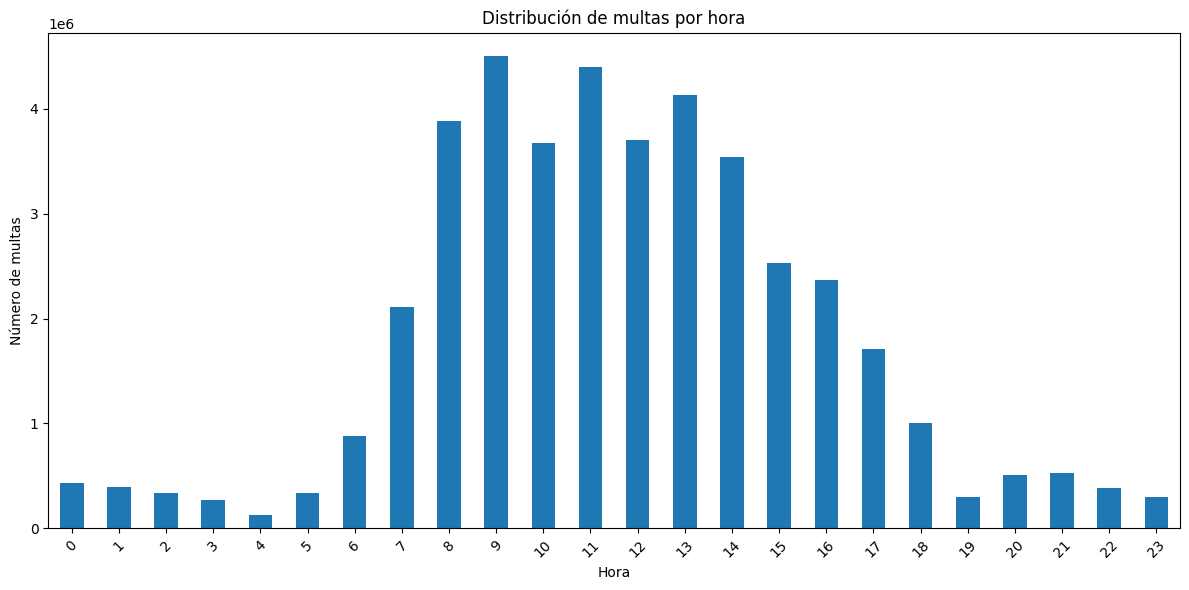

In [22]:
hourly_counts = hourly_counts.to_pandas()

# Creamos el gráfico de barras
plt.figure(figsize=(12, 6))
hourly_counts.iloc[:24].plot(kind="bar")
plt.title("Distribución de multas por hora")
plt.xlabel("Hora")
plt.ylabel("Número de multas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
del hourly_counts

---

5. Tipos de infracción más comunes: Encontrar cuáles son las infracciones de estacionamiento más frecuentes en NYC.


In [24]:
# Realizamos el conteo de multas por cada tipo de'Violation Description', ordenamos y nos quedamos
# con las 10 más frecuentes
violation_counts = (
    df["Violation Description"].value_counts(sort=True).nlargest(10).compute()
)

# Mostramos los resultados
print("Las 10 infracciones de estacionamiento más frecuentes son:")
print(violation_counts.head(10))

Las 10 infracciones de estacionamiento más frecuentes son:
Violation Description
21-No Parking (street clean)      4954662
38-Failure to Display Muni Rec    4833587
PHTO SCHOOL ZN SPEED VIOLATION    3583078
14-No Standing                    3244603
37-Expired Muni Meter             2800752
FAILURE TO STOP AT RED LIGHT      2161754
20A-No Parking (Non-COM)          1881504
71A-Insp Sticker Expired (NYS)    1765219
40-Fire Hydrant                   1573012
69-Failure to Disp Muni Recpt      957268
Name: count, dtype: int64


In [25]:
del violation_counts

---

6. Zonas con mayor número de multas: Identificar las ubicaciones de la ciudad con más infracciones registradas (e.g., Calle).

In [26]:
# Realizamos el conteo de multas por cada calle de NYC, ordenamos y nos quedamos
# con las 10 que son más propensas a que hayan multas
street_counts = df["Street Name"].value_counts(sort=True).nlargest(10).compute()

# Mostramos los resultados
print("Las 10 calles con más multas son:")
print(street_counts.head(10))

Las 10 calles con más multas son:
Street Name
Broadway         859474
3rd Ave          650506
5th Ave          414020
Madison Ave      394063
Lexington Ave    335943
2nd Ave          313403
1st Ave          294659
7th Ave          264017
Queens Blvd      243205
8th Ave          235267
Name: count, dtype: int64


In [27]:
del street_counts